In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams['image.cmap'] = 'bwr'

from src import *

# Experiment 2

Hypothesis:

- Uniform $\mathcal{X}$ distribution (shouldn't impact the results)
- Each pixel $y_i$ from the ground-truth is drawn from a beta distribution with $a=b=0.5$. This renders the output probability separable, i.e., $$P(Y=y|X=x) = \prod_{i=1}^{n} P(Y_i=y_i|X=x)$$
- A model for the marginal probabilities is available and estimates them with a logit gaussian noise

In [3]:
# random pixel-level output probability
Pyi = np.array([np.random.RandomState(x).beta(a=0.5, b=0.5, size=(3,3)) for x in range(2**9)])

# image-level output probability derived from pixel-level probabilities
Py = [np.array([np.where(int2img(y), Pyi[x], 1 - Pyi[x]).prod() for y in range(2**9)]) for x in range(2**9)]

In [4]:
# pixel-level probability is predicted with a gaussian noise at the logits
def hatpyi(x):
    z = sp.special.logit(Pyi[x])
    zhat = np.random.RandomState(x).normal(z, scale=1.0)
    return sp.special.expit(zhat)

# I think the following is more efficient, but I'm not risking it now
# def pyhat(y, x):
#     return np.abs((1-int2img(y)) - pyihat(x)).prod()

hatPyi = [hatpyi(x) for x in np.arange(2**9)]
hatPy = [np.array([np.where(int2img(y), pyi, 1 - pyi).prod() for y in np.arange(2**9)]) for pyi in hatPyi]

## Example

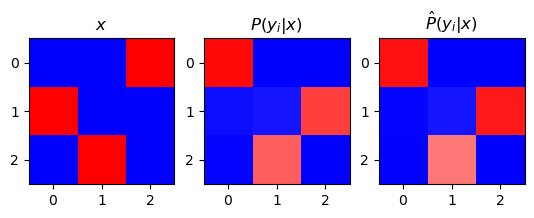

In [5]:
x = np.random.choice(2**9)

fig, axs = plt.subplots(1, 3)

axs[0].imshow(int2img(x))
axs[0].set_title('$x$')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title(r'$P(y_i|x)$')

axs[2].imshow(hatPyi[x], vmin=0, vmax=1)
axs[2].set_title(r'$\hat{P}(y_i|x)$')

plt.show()

## 0-1 & accuracy ideal model

The ideal model for the 0-1 loss given the model for the marginal probabilities is $$ h(x) = \arg\max_{\hat{y}} \, \hat{P}(Y=\hat{y}|X=x). $$
Because the probability is separable, it is easy to see that this model is also the ideal model for the accuracy loss.

In [6]:
# most probable output
h = lambda x: np.argmax(hatPy[x])

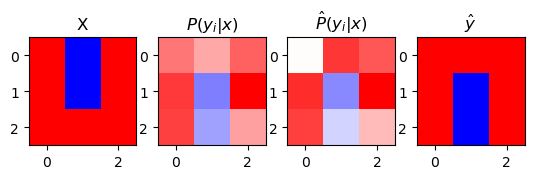

In [7]:
## EXAMPLE
x = np.random.choice(2**9)
y_hat = h(x)

fig, axs = plt.subplots(1, 4)

axs[0].imshow(int2img(x))
axs[0].set_title('X')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title(r'$P(y_i|x)$')

axs[2].imshow(hatPyi[x], vmin=0, vmax=1)
axs[2].set_title(r'$\hat{P}(y_i|x)$')

axs[3].imshow(int2img(y_hat))
axs[3].set_title(r'$\hat{y}$')

plt.show()

### Losses

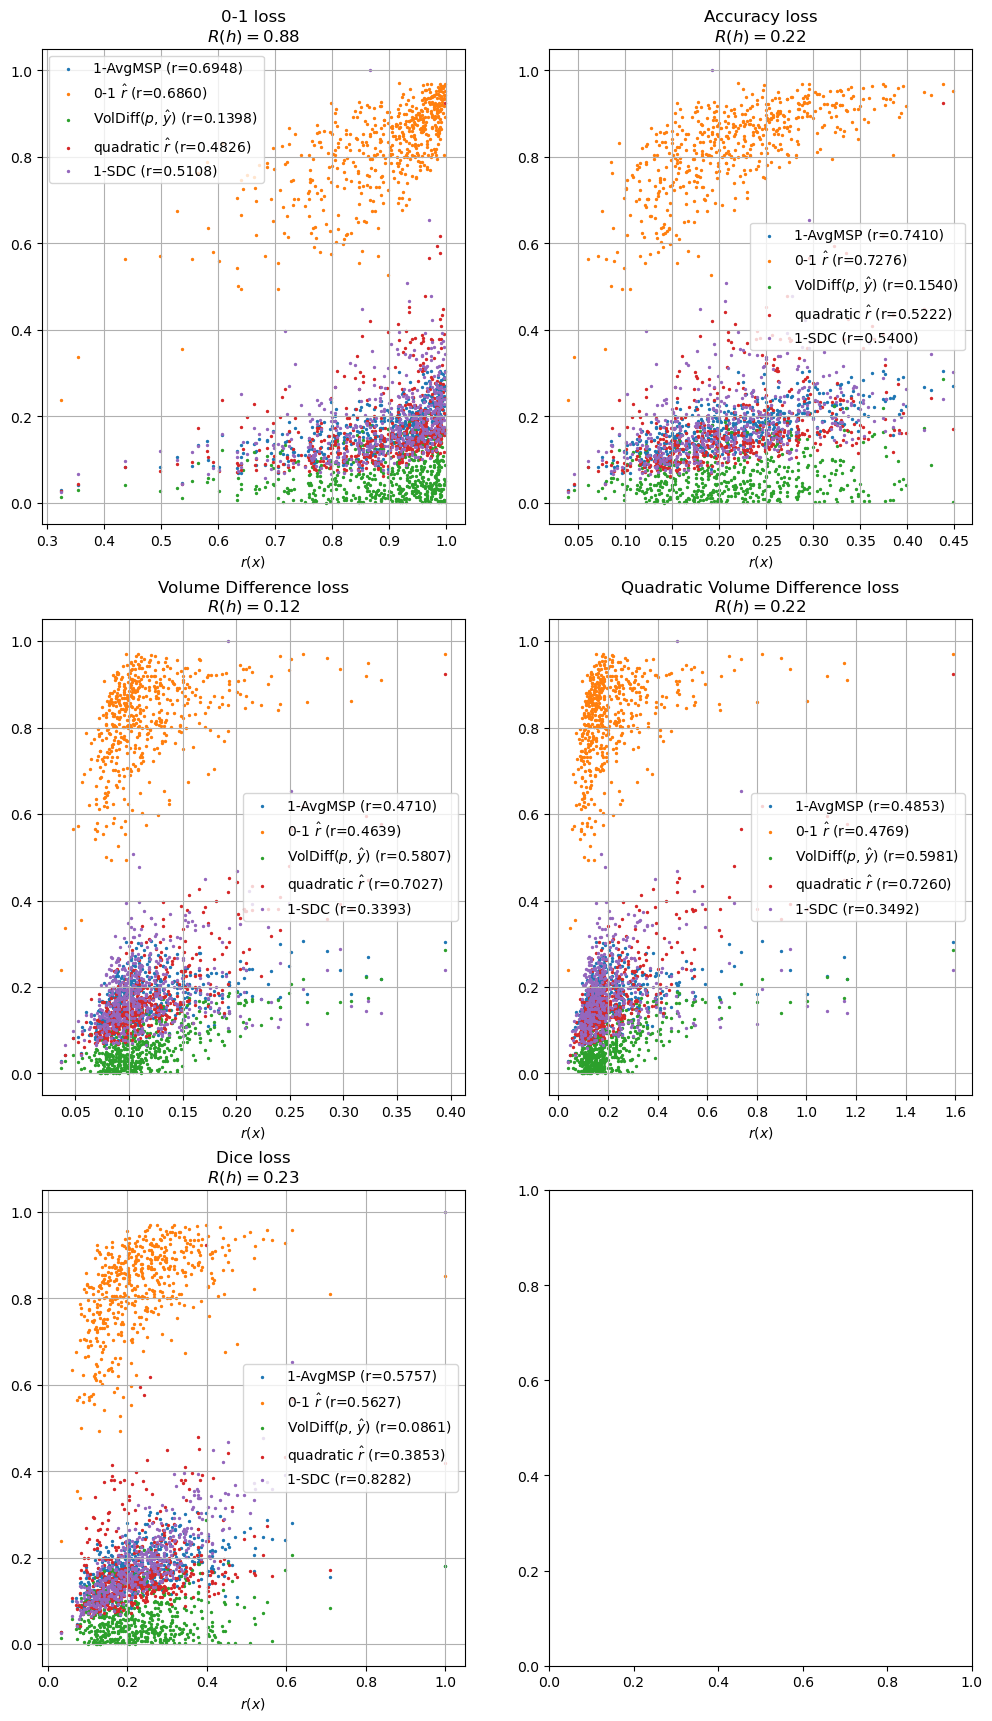

In [8]:
all_plots = [plot_01_loss, plot_accuracy_loss, plot_voldiff_loss, plot_quadvoldiff_loss, plot_dice_loss]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_loss, ax in zip(all_plots, axs.flatten()):
    plot_loss(h, Py, hatPyi, ax=ax)
plt.show()

### RC Curves

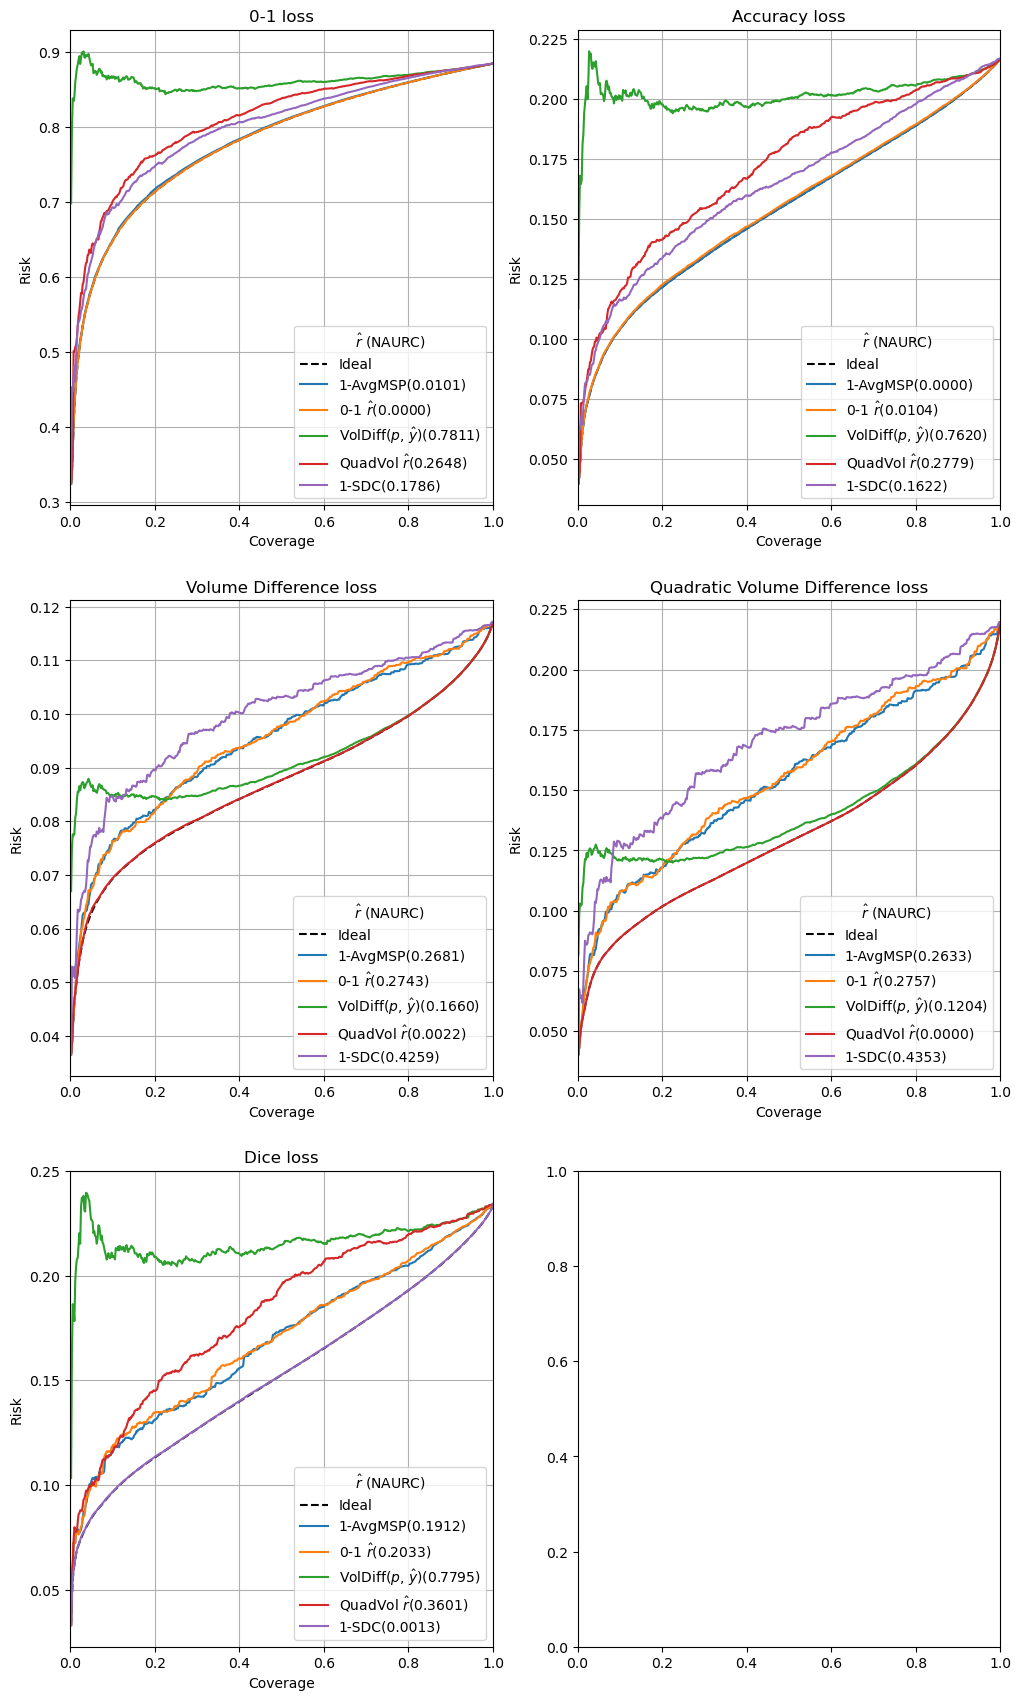

In [9]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

## Max Dice model

The ideal model for the Dice loss is the one that minimizes the conditional risk $ h(x) = \arg\min_{\hat{y}} r_{DSC}(x,\hat{y}) $, where $$ r_{DSC}(x,\hat{y}) = \sum_y P(Y=y|X=x) DSC(y,\hat{y}) . $$

In [10]:
Y = list(range(2**9))

y_true = lambda x: np.argmax(Py[x])

def dice_loss(y, y_hat):
    if y == 0:
        if y_hat == 0:
            return 0
        else:
            return 1
    else:
        return 1 - 2 * (int2img(y) * int2img(y_hat)).sum() / (int2img(y).sum() + int2img(y_hat).sum() + 1)

AllDiceLosses = np.array([np.array([dice_loss(y1, y2) for y2 in Y]) for y1 in Y])

In [11]:
# precompute the risk associated to each y given x
Ry_dice = np.array([AllDiceLosses @ hatPy[x] for x in range(2**9)])  # Ry_dice[x,y] $\gets r_dice(x|h(x) = y)$

# model minimizes the DICE loss, i.e., picks the target with the lowest
# predicted conditional risk y^ = argmin_y r^(x|h(x)=y)
h = lambda x: np.argmin(Ry_dice[x])

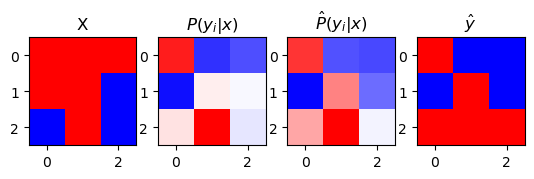

In [12]:
## EXAMPLE
x = np.random.choice(2**9)
y_hat = h(x)

fig, axs = plt.subplots(1, 4)

axs[0].imshow(int2img(x))
axs[0].set_title('X')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title(r'$P(y_i|x)$')

axs[2].imshow(hatPyi[x], vmin=0, vmax=1)
axs[2].set_title(r'$\hat{P}(y_i|x)$')

axs[3].imshow(int2img(y_hat))
axs[3].set_title(r'$\hat{y}$')

plt.show()

### Losses

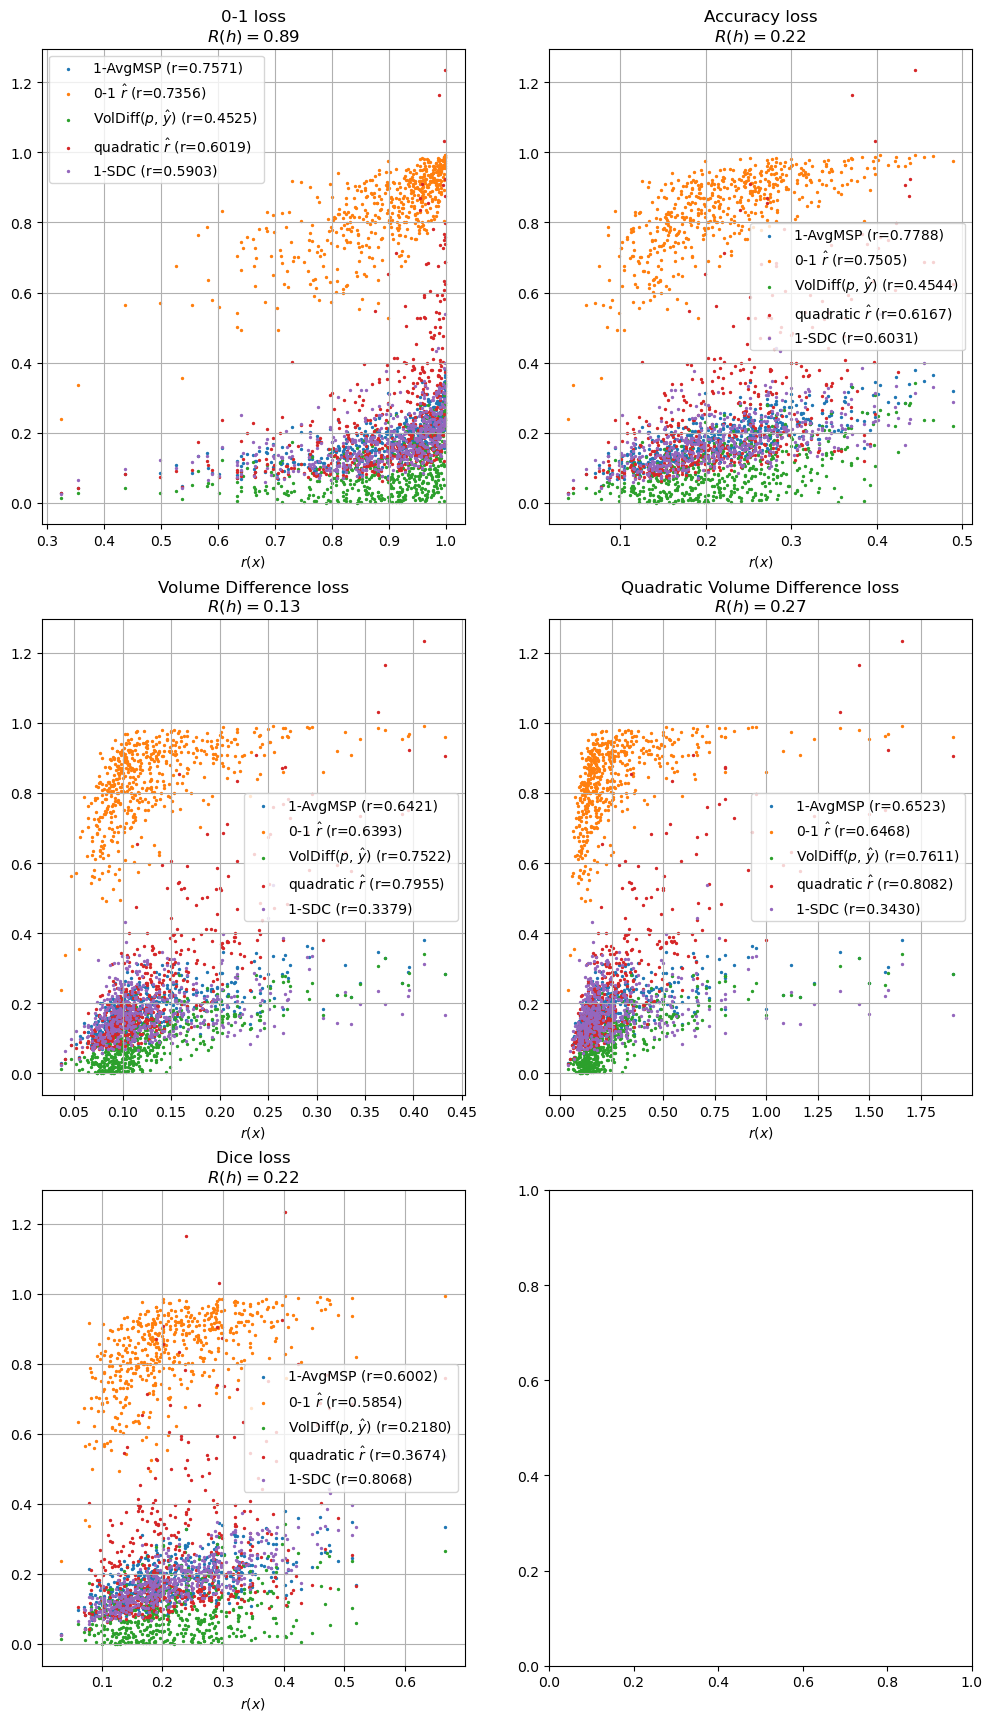

In [13]:
all_plots = [plot_01_loss, plot_accuracy_loss, plot_voldiff_loss, plot_quadvoldiff_loss, plot_dice_loss]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_loss, ax in zip(all_plots, axs.flatten()):
    plot_loss(h, Py, hatPyi, ax=ax)
plt.show()

### RC Curves

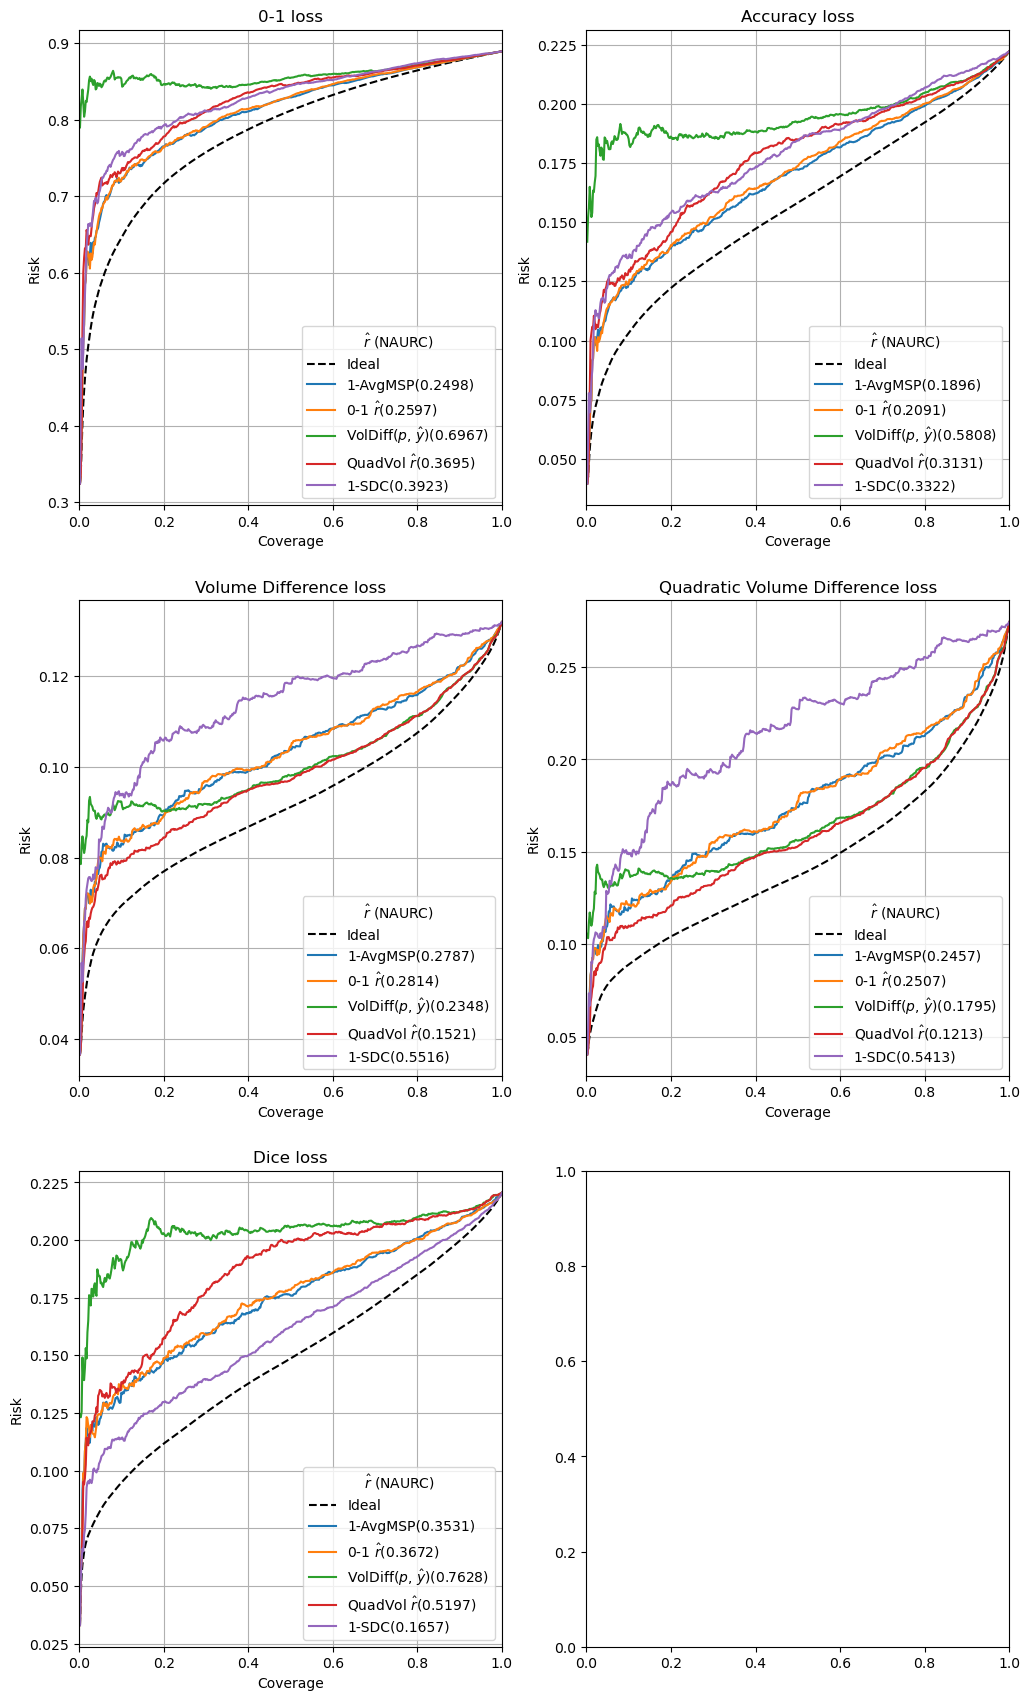

In [14]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# all_plots = [plot_01_rc,]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, hatPyi, ax=ax)
plt.show()

## Variable Noise

In [15]:
def get_hatPyi(Pyi, scale=1.0):
    # pixel-level probability is predicted with a gaussian noise at the logits
    def hatpyi(x):
        z = sp.special.logit(Pyi[x])
        zhat = np.random.RandomState(x).normal(z, scale=scale)
        return sp.special.expit(zhat)

    hatPyi = [hatpyi(x) for x in np.arange(2**9)]
    hatPy = [np.array([np.where(int2img(y), pyi, 1 - pyi).prod() for y in np.arange(2**9)]) for pyi in hatPyi]

    return hatPyi, hatPy

loss_01 = lambda y, y_hat: 1-int(y == y_hat)
loss_acc = lambda y, y_hat: 1 - (int2img(y) == int2img(y_hat)).mean()
loss_dsc = lambda y, y_hat: 1 - 2 * (int2img(y) * int2img(y_hat)).sum() / (int2img(y).sum() + int2img(y_hat).sum()+1e-3)
loss_sve = lambda y, y_hat: (int2img(y).sum(dtype=float) - int2img(y_hat).sum(dtype=float))**2 / 9

### 0-1 & accuracy ideal model

In [16]:
def get_h(hatPy):
    return lambda x: np.argmax(hatPy[x])

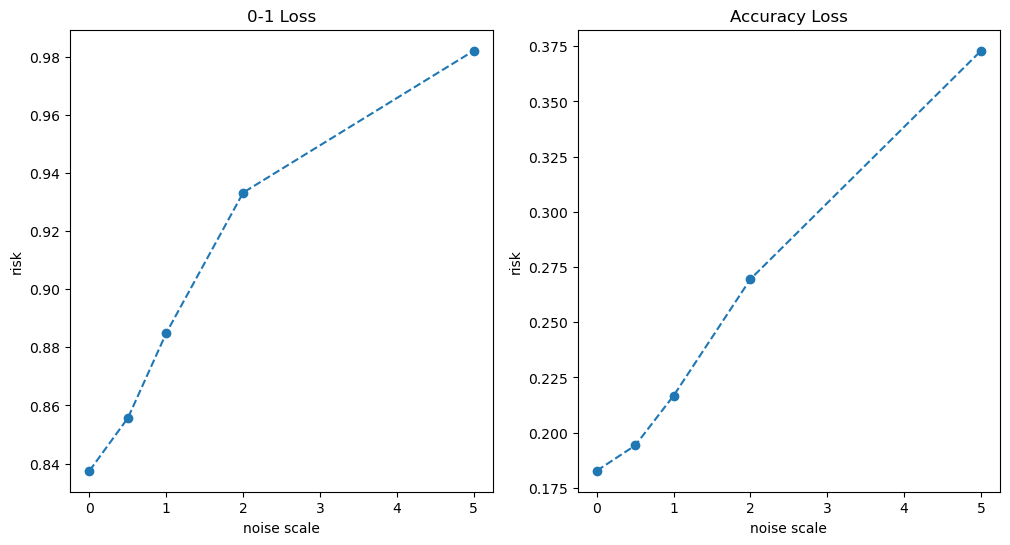

In [17]:
risks_01 = list()
risks_acc = list()

noise_range = [0.0, 0.5, 1.0, 2.0, 5.0]
for s in noise_range:
    _, hatPy = get_hatPyi(Pyi, scale=s)
    h = get_h(hatPy)

    r_01 = get_true_conditional_risk(loss_01, Py, h)
    R_01 = np.vectorize(r_01)(X).mean()
    risks_01.append(R_01)

    r_acc = get_true_conditional_risk(loss_acc, Py, h)
    R_acc = np.vectorize(r_acc)(X).mean()
    risks_acc.append(R_acc)

fig, axs = plt.subplots(1, 2)
fig.set_size_inches(2*6, 6)

axs[0].plot(noise_range, risks_01, '--o')
axs[0].set_title('0-1 Loss')
axs[0].set_xlabel('noise scale')
axs[0].set_ylabel('risk')

axs[1].plot(noise_range, risks_acc, '--o')
axs[1].set_title('Accuracy Loss')
axs[1].set_xlabel('noise scale')
axs[1].set_ylabel('risk')

plt.show()

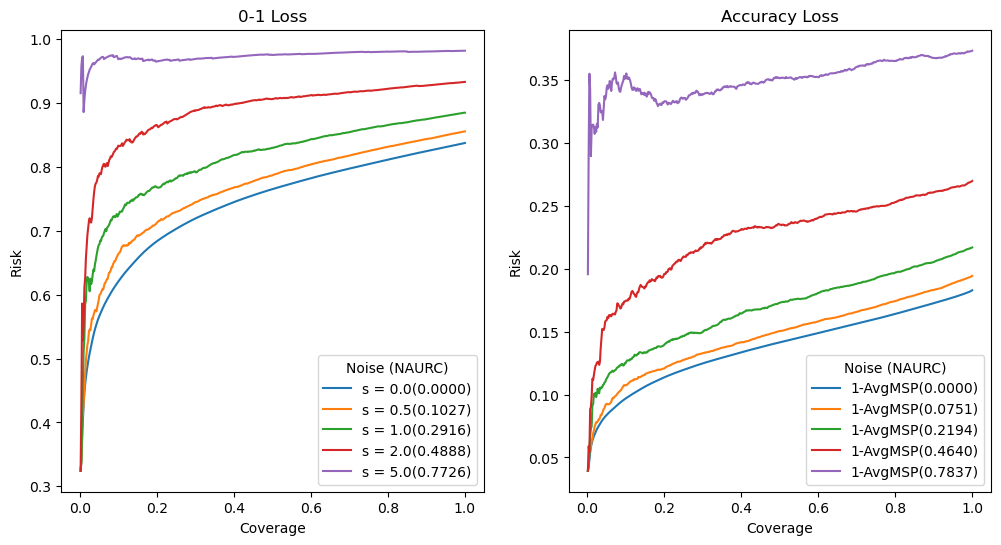

In [18]:
noise_range = [0.0, 0.5, 1.0, 2.0, 5.0]
fig, axs = plt.subplots(1, 2)
fig.set_size_inches(2*6, 6)

for s in noise_range:
    hatPyi, hatPy = get_hatPyi(Pyi, scale=s)
    h = get_h(hatPy)

    ## 01
    r_01 = get_true_conditional_risk(loss_01, Py, h)
    R_01 = np.vectorize(r_01)(X)
    risks, coverages = rc_curve(-R_01, h, Py, loss_01)

    ideal_aurc = auc(coverages, risks)
    random_aurc = np.max(risks)

    plot_rc_curve(axs[0], get_01_rhat(h, hatPyi), h, Py, loss_01, r"s = %.1f" % s, ideal_aurc, random_aurc)

    ## Accuracy
    r_acc = get_true_conditional_risk(loss_acc, Py, h)
    R_acc = np.vectorize(r_acc)(X)
    risks, coverages = rc_curve(-R_acc, h, Py, loss_acc)

    ideal_aurc = auc(coverages, risks)
    random_aurc = np.max(risks)

    plot_rc_curve(axs[1], get_avg_msp_rhat(h, hatPyi), h, Py, loss_acc, "1-AvgMSP", ideal_aurc, random_aurc)

axs[0].legend(title="Noise (NAURC)")
axs[0].set_title("0-1 Loss")
axs[0].set_xlabel("Coverage")
axs[0].set_ylabel("Risk")

axs[1].legend(title="Noise (NAURC)")
axs[1].set_title("Accuracy Loss")
axs[1].set_xlabel("Coverage")
axs[1].set_ylabel("Risk")

fig.show()

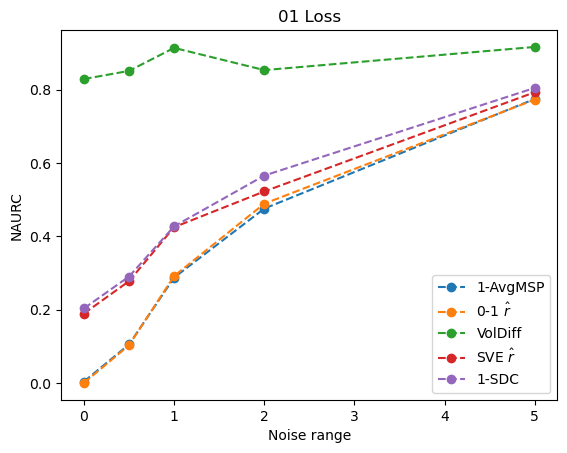

In [19]:
noise_range = [0.0, 0.5, 1.0, 2.0, 5.0]
get_r_hats = {
    r'1-AvgMSP': get_avg_msp_rhat,
    r'0-1 $\hat{r}$': get_01_rhat,
    r'VolDiff': get_softvoldiff,
    r'SVE $\hat{r}$': get_quadvoldiff_rhat,
    r'1-SDC': get_softdice_risk,
}
naurcs = {
    r'1-AvgMSP': list(),
    r'0-1 $\hat{r}$': list(),
    r'VolDiff': list(),
    r'SVE $\hat{r}$': list(),
    r'1-SDC': list(),
}

for s in noise_range:
    hatPyi, hatPy = get_hatPyi(Pyi, scale=s)
    h = get_h(hatPy)

    r = get_true_conditional_risk(loss_01, Py, h)
    R = np.vectorize(r)(X)
    risks, coverages = rc_curve(-R, h, Py, loss_01)

    ideal_aurc = auc(coverages, risks)
    random_aurc = np.max(risks)

    for r_name in naurcs.keys():
        r_hat = get_r_hats[r_name](h, hatPyi)

        risks, coverages = rc_curve(-np.vectorize(r_hat)(X), h, Py, loss_01)
        naurc = (auc(coverages, risks) - ideal_aurc) / (random_aurc - ideal_aurc)
        naurcs[r_name].append(naurc)

for r_name in naurcs.keys():
    plt.plot(noise_range, naurcs[r_name], '--o', label=r_name)

plt.legend()
plt.title("01 Loss")
plt.xlabel("Noise range")
plt.ylabel("NAURC")

plt.show()

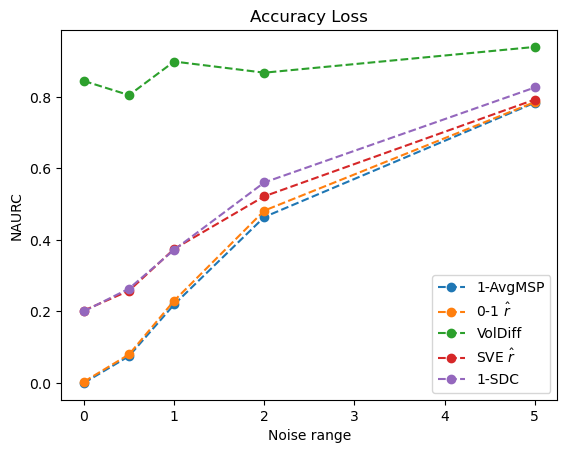

In [20]:
noise_range = [0.0, 0.5, 1.0, 2.0, 5.0]
get_r_hats = {
    r'1-AvgMSP': get_avg_msp_rhat,
    r'0-1 $\hat{r}$': get_01_rhat,
    r'VolDiff': get_softvoldiff,
    r'SVE $\hat{r}$': get_quadvoldiff_rhat,
    r'1-SDC': get_softdice_risk,
}
naurcs = {
    r'1-AvgMSP': list(),
    r'0-1 $\hat{r}$': list(),
    r'VolDiff': list(),
    r'SVE $\hat{r}$': list(),
    r'1-SDC': list(),
}

for s in noise_range:
    hatPyi, hatPy = get_hatPyi(Pyi, scale=s)
    h = get_h(hatPy)

    r = get_true_conditional_risk(loss_acc, Py, h)
    R = np.vectorize(r)(X)
    risks, coverages = rc_curve(-R, h, Py, loss_acc)

    ideal_aurc = auc(coverages, risks)
    random_aurc = np.max(risks)

    for r_name in naurcs.keys():
        r_hat = get_r_hats[r_name](h, hatPyi)

        risks, coverages = rc_curve(-np.vectorize(r_hat)(X), h, Py, loss_acc)
        naurc = (auc(coverages, risks) - ideal_aurc) / (random_aurc - ideal_aurc)
        naurcs[r_name].append(naurc)

for r_name in naurcs.keys():
    plt.plot(noise_range, naurcs[r_name], '--o', label=r_name)

plt.legend()
plt.title("Accuracy Loss")
plt.xlabel("Noise range")
plt.ylabel("NAURC")

plt.show()

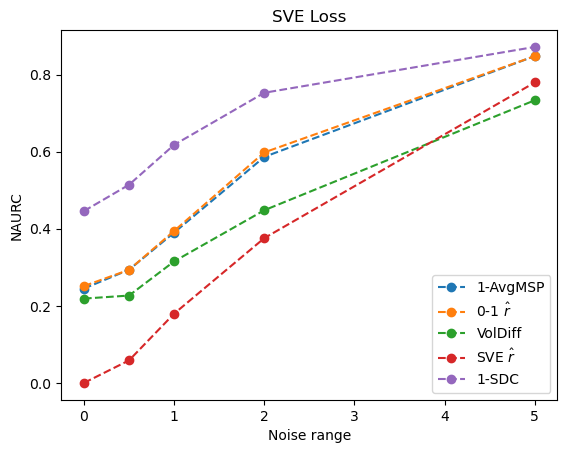

In [21]:
noise_range = [0.0, 0.5, 1.0, 2.0, 5.0]
get_r_hats = {
    r'1-AvgMSP': get_avg_msp_rhat,
    r'0-1 $\hat{r}$': get_01_rhat,
    r'VolDiff': get_softvoldiff,
    r'SVE $\hat{r}$': get_quadvoldiff_rhat,
    r'1-SDC': get_softdice_risk,
}
naurcs = {
    r'1-AvgMSP': list(),
    r'0-1 $\hat{r}$': list(),
    r'VolDiff': list(),
    r'SVE $\hat{r}$': list(),
    r'1-SDC': list(),
}

for s in noise_range:
    hatPyi, hatPy = get_hatPyi(Pyi, scale=s)
    h = get_h(hatPy)

    r = get_true_conditional_risk(loss_sve, Py, h)
    R = np.vectorize(r)(X)
    risks, coverages = rc_curve(-R, h, Py, loss_sve)

    ideal_aurc = auc(coverages, risks)
    random_aurc = np.max(risks)

    for r_name in naurcs.keys():
        r_hat = get_r_hats[r_name](h, hatPyi)

        risks, coverages = rc_curve(-np.vectorize(r_hat)(X), h, Py, loss_sve)
        naurc = (auc(coverages, risks) - ideal_aurc) / (random_aurc - ideal_aurc)
        naurcs[r_name].append(naurc)

for r_name in naurcs.keys():
    plt.plot(noise_range, naurcs[r_name], '--o', label=r_name)

plt.legend()
plt.title("SVE Loss")
plt.xlabel("Noise range")
plt.ylabel("NAURC")

plt.show()

### Dice ideal model

In [22]:
def get_h(hatPy):
    Ry_dice = np.array([AllDiceLosses @ hatPy[x] for x in range(2**9)])  # Ry_dice[x,y] $\gets r_dice(x|h(x) = y)$

    return lambda x: np.argmin(Ry_dice[x])

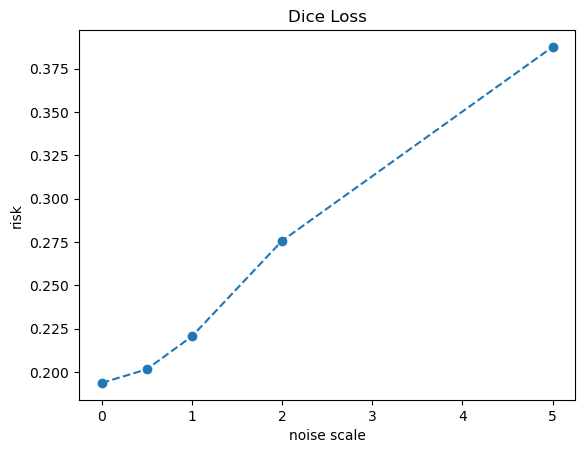

In [23]:
risks_dsc = list()

noise_range = [0.0, 0.5, 1.0, 2.0, 5.0]
for s in noise_range:
    _, hatPy = get_hatPyi(Pyi, scale=s)
    h = get_h(hatPy)

    r = get_true_conditional_risk(loss_dsc, Py, h)
    R = np.vectorize(r)(X).mean()
    risks_dsc.append(R)

plt.plot(noise_range, risks_dsc, '--o')
plt.title('Dice Loss')
plt.xlabel('noise scale')
plt.ylabel('risk')

plt.show()

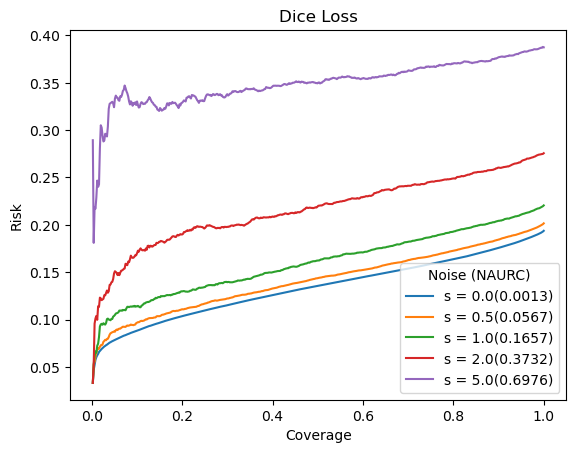

In [24]:
noise_range = [0.0, 0.5, 1.0, 2.0, 5.0]

for s in noise_range:
    hatPyi, hatPy = get_hatPyi(Pyi, scale=s)
    h = get_h(hatPy)

    r = get_true_conditional_risk(loss_dsc, Py, h)
    R = np.vectorize(r)(X)
    risks, coverages = rc_curve(-R, h, Py, loss_dsc)

    ideal_aurc = auc(coverages, risks)
    random_aurc = np.max(risks)

    plot_rc_curve(plt.gca(), get_softdice_risk(h, hatPyi), h, Py, loss_dsc, r"s = %.1f" % s, ideal_aurc, random_aurc)

plt.legend(title="Noise (NAURC)")
plt.title("Dice Loss")
plt.xlabel("Coverage")
plt.ylabel("Risk")

plt.show()

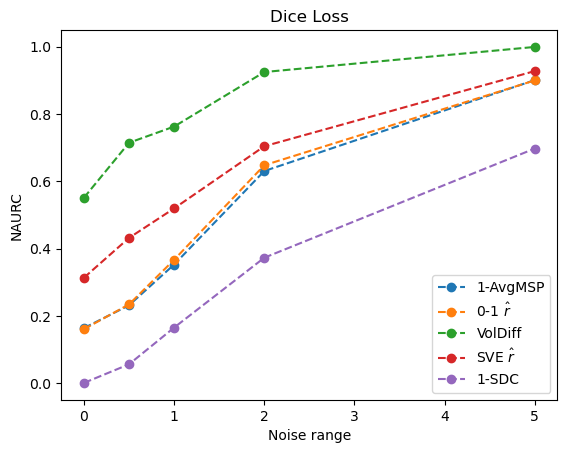

In [25]:
noise_range = [0.0, 0.5, 1.0, 2.0, 5.0]
get_r_hats = {
    r'1-AvgMSP': get_avg_msp_rhat,
    r'0-1 $\hat{r}$': get_01_rhat,
    r'VolDiff': get_softvoldiff,
    r'SVE $\hat{r}$': get_quadvoldiff_rhat,
    r'1-SDC': get_softdice_risk,
}
naurcs = {
    r'1-AvgMSP': list(),
    r'0-1 $\hat{r}$': list(),
    r'VolDiff': list(),
    r'SVE $\hat{r}$': list(),
    r'1-SDC': list(),
}

for s in noise_range:
    hatPyi, hatPy = get_hatPyi(Pyi, scale=s)
    h = get_h(hatPy)

    r = get_true_conditional_risk(loss_dsc, Py, h)
    R = np.vectorize(r)(X)
    risks, coverages = rc_curve(-R, h, Py, loss_dsc)

    ideal_aurc = auc(coverages, risks)
    random_aurc = np.max(risks)

    for r_name in naurcs.keys():
        r_hat = get_r_hats[r_name](h, hatPyi)

        risks, coverages = rc_curve(-np.vectorize(r_hat)(X), h, Py, loss_dsc)
        naurc = (auc(coverages, risks) - ideal_aurc) / (random_aurc - ideal_aurc)
        naurcs[r_name].append(naurc)

for r_name in naurcs.keys():
    plt.plot(noise_range, naurcs[r_name], '--o', label=r_name)

plt.legend()
plt.title("Dice Loss")
plt.xlabel("Noise range")
plt.ylabel("NAURC")

plt.show()

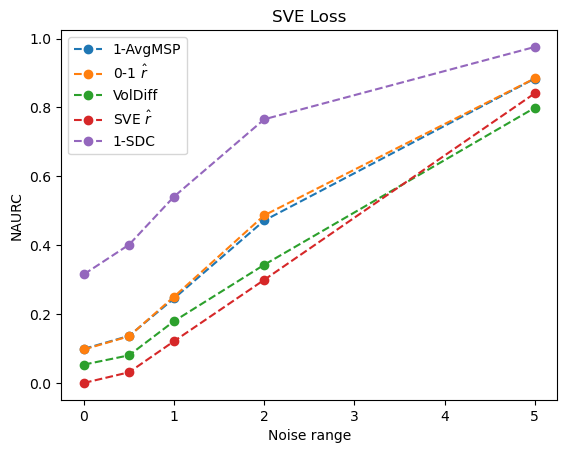

In [26]:
noise_range = [0.0, 0.5, 1.0, 2.0, 5.0]
get_r_hats = {
    r'1-AvgMSP': get_avg_msp_rhat,
    r'0-1 $\hat{r}$': get_01_rhat,
    r'VolDiff': get_softvoldiff,
    r'SVE $\hat{r}$': get_quadvoldiff_rhat,
    r'1-SDC': get_softdice_risk,
}
naurcs = {
    r'1-AvgMSP': list(),
    r'0-1 $\hat{r}$': list(),
    r'VolDiff': list(),
    r'SVE $\hat{r}$': list(),
    r'1-SDC': list(),
}

for s in noise_range:
    hatPyi, hatPy = get_hatPyi(Pyi, scale=s)
    h = get_h(hatPy)

    r = get_true_conditional_risk(loss_sve, Py, h)
    R = np.vectorize(r)(X)
    risks, coverages = rc_curve(-R, h, Py, loss_sve)

    ideal_aurc = auc(coverages, risks)
    random_aurc = np.max(risks)

    for r_name in naurcs.keys():
        r_hat = get_r_hats[r_name](h, hatPyi)

        risks, coverages = rc_curve(-np.vectorize(r_hat)(X), h, Py, loss_sve)
        naurc = (auc(coverages, risks) - ideal_aurc) / (random_aurc - ideal_aurc)
        naurcs[r_name].append(naurc)

for r_name in naurcs.keys():
    plt.plot(noise_range, naurcs[r_name], '--o', label=r_name)

plt.legend()
plt.title("SVE Loss")
plt.xlabel("Noise range")
plt.ylabel("NAURC")

plt.show()

## Comments

I don't have many insights from these experiments. Noise seems to worsen the performance of confidence estimators, but does not make the ideal confidence estimator worse than any other. In fact, we don't see any change in the ranks when staying under acceptable risk levels, i.e., changes seem to happen only when a strong noise is applied (scale of 5) and the performance is really bad.